# Decision Trees, Random Forest and XGBoost

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [Decision Tree](#dt)
3. [Random Forest](#rf)
4. [XGBoost](#XGBoost)
5. [Exercise](#exercise)

In this notebook we will use XGBoost. We need another library: 

In [119]:
!uv pip install xgboost

"uv" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [120]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

The dataset used is the Wine dataset, a classic dataset in machine learning containing chemical properties of wines and their corresponding classes.

Let's load and prepare the data:

In [121]:
wine = load_wine()
X = wine.data
y = wine.target

We divide the data into train and test: 

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

<div class="alert alert-warning">
    <b> IV. <i>Decision Tree </i></b>
    <a id="dt"></a></div>

A Decision Tree is a supervised machine learning algorithm. It works by splitting the data into smaller subsets based on feature values, forming a tree-like structure of decisions. Each node represents a decision based on a feature, each branch represents the outcome of that decision and each leaf represents a final prediction.


We can put the following parameters: 
- ``random_state``: ensures same tree each run.

- ``max_depth``: limits how deep the tree can grow preventing the model from becoming too complex. If we use a small depth, the model is simpler and may underfit. If we use a larger depth, the model can become too complex and overfit. 

- ``min_samples_split``: minimum samples to split a node. If we use a higher value, there will be fewer splits and the tree is simpler. Otherwise, the tree becomes more complex. This value helps to control overfitting. 

- ``criterion``: It is a function used to measure the quality of a split. It usually takes "gini" or "entropy". Gini is more commonly used.

In [123]:
dt = DecisionTreeClassifier(random_state=42)

Let's train with the training data:

In [124]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Perform predictions on the evaluation set: 

In [125]:
y_pred_dt = dt.predict(X_test)

Then, we evaluate the performance:

In [126]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



We can visualize the decision tree: 

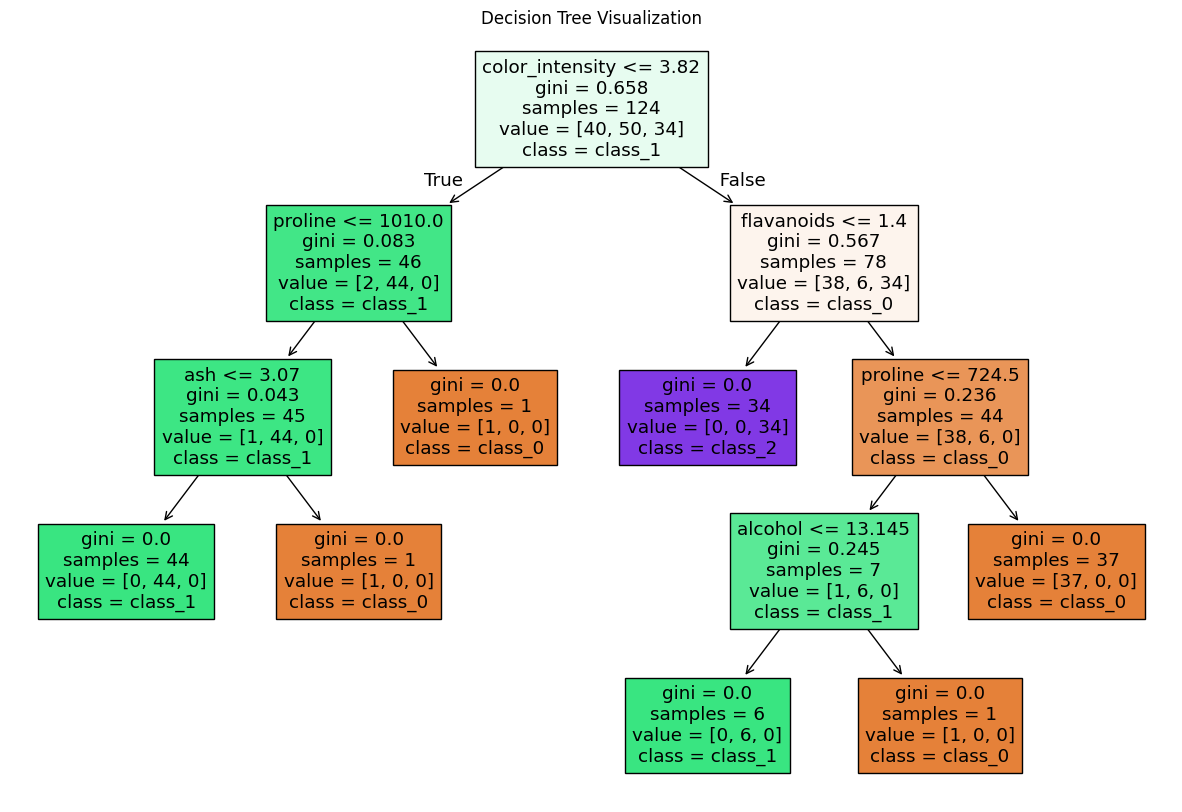

In [127]:
plt.figure(figsize=(15,10))
plot_tree(
    dt,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

The model is making decisions by asking questions about the features. Each box shows the condition (for example, ``color intensity``), the number of samples ( ``samples``), number of samples per class (``value``) and the predicted class by majority (``class``). The ``gini`` value measures how mixed the classes are in a node, if it is closer to 0 the data is mostly one class. A high gini the data is more mixed.

<div class="alert alert-info">

_Try different values of max_depth, min_samples_split. You can use GridSearchCV (remember to import the library)_

In [128]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
0.9353333333333333
Decision Tree Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



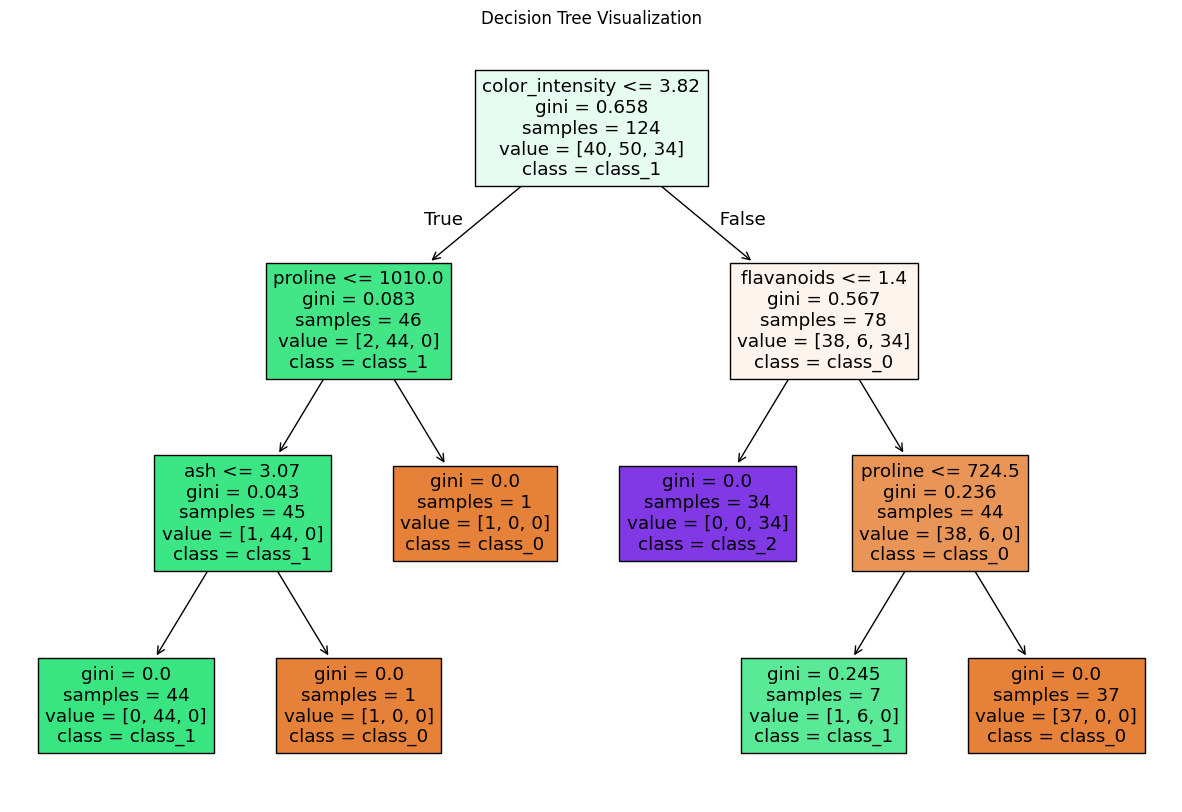

In [129]:
plt.figure(figsize=(15,10))
plot_tree(
    grid.best_estimator_,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

<div class="alert alert-warning">
    <b> IV. <i>Random Forest </i></b>
    <a id="Exercise"></a></div>

A Random Forest is an ensemble learning method that builds many decision trees and combines their predictions. Instead of relying on a single tree, trains multiple trees on different subsets of the data. 

- ``n_estimators``: Number of trees in the forest. More trees usually brings better performance. 
- ``random_state``: Controls randomness.
- ``max_depth``: Maximum depth of each tree.
- ``min_samples_split``: Minimum number of samples required to split a node.
- ``max_features``: Number of features considered at each split. There are different options: ``sqrt``(compute the square root), ``log2``(compute the logarithm of the features $log_2$(features)), fixed number or a percentage

In [130]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

Let's train the random forest:

In [131]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Perform predictions:

In [132]:
y_pred_rf = rf.predict(X_test)

Evaluate the model: 

In [133]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



<div class="alert alert-info">

_Try different values of n_estimators,max_features, max_depth, min_samples_split. You can use GridSearchCV_

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    n_jobs=-1)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)
y_pred = grid.best_estimator_.predict(X_test)


print("Random Forest Accuracy:",  accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}
0.968
Random Forest Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      0.90      0.95        21
           2       1.00      1.00      1.00        14

    accuracy                           0.96        54
   macro avg       0.97      0.97      0.97        54
weighted avg       0.97      0.96      0.96        54



<div class="alert alert-warning">
    <b> IV. <i>XGBoost </i></b>
    <a id="XGBoost"></a></div>

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on boosting.

__What is boosting?__

Boosting is a machine learning technique that combines multiple weak models (usually small decision trees) to create a strong, accurate model. It trains a simple model, checks where it makes mistakes, gives more importance to those mistakes and trains a new model focusing on those errors. It repeats this process multiple times. Then, combines all the models into one final prediction. 

The parameters used are: 
- ``n_estimators``: Number of trees or boosting rounds. The more trees, better learning but we risk to overfitting. 
- ``max_depth``: Maximum depth of each tree.
- ``learning_rate``:  Step size for updating predictions. Giving a small value (0.01), learns slowly but can obtain better accuracy. Using a large value, learns faster but can miss an optimal solution. 
- ``eval_metric``: Evaluation metric used during training. We have ``auc`` for binary classification, ``mlogloss`` is multiclass log loss and measures how well predicted the probabilities match the ture labels. 
- ``random_state``: Controls randomness.
- ``subsample``: fraction of samples used per tree.
- ``colsample_bytree``: Fraction of features (columns) used for each tree
- ``gamma``: Minimum loss reduction required to make a split. Controls how strict the model is when creating splits. If we put a 0, the model splits more easily.  

There are much more parameters available: [Link to documentation](https://xgboost.readthedocs.io/en/stable/parameter.html)

In [135]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='auc',
    random_state=42
)

In [136]:
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [137]:
y_pred_xgb = xgb.predict(X_test)


In [138]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9814814814814815
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

